# AR(1) Adequacy Test — Apr–Sep by Year (2022–2025)

**목적**: TCO 데이터의 시간 의존 구조가 AR(1)으로 적합한지 연도별로 검증  
**데이터**: `GEMS_DATA/Apr_to_Sep/tco_grid_apr_sep_{year}.pkl`  
**시간 스케일**: 8-hour daily snapshots (intra-day) + day-to-day (daily mean)

## 분석 구조
1. 공간 평균 시계열 추출 (대표적인 시계열)
2. 고정 격자점 시계열 추출 (개별 위치)
3. ACF / PACF 시각화
4. AR(p) 차수 선택 (AIC/BIC)
5. Ljung-Box test on AR(1) residuals
6. 연도별 비교 요약

In [1]:
import sys, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from statsmodels.tsa.stattools import acf, pacf, adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sys.path.append("/Users/joonwonlee/Documents/GEMS_TCO-1/src")
from GEMS_TCO import configuration as config

DATA_DIR = Path(config.mac_data_load_path) / "Apr_to_Sep"
YEARS    = [2022, 2023, 2024, 2025]
print("DATA_DIR:", DATA_DIR)
print("Files:", [f.name for f in sorted(DATA_DIR.glob("*.pkl"))])

DATA_DIR: /Users/joonwonlee/Documents/GEMS_DATA/Apr_to_Sep
Files: ['tco_grid_apr_sep_2022.pkl', 'tco_grid_apr_sep_2023.pkl', 'tco_grid_apr_sep_2024.pkl', 'tco_grid_apr_sep_2025.pkl']


In [2]:
# ── Load day_index and monthly_means ─────────────────────────────────────────
day_index_df = pd.read_csv(DATA_DIR / "day_index_apr_sep_2022_2025.csv")
mm_df        = pd.read_csv(DATA_DIR / "monthly_means_apr_sep_2022_2025.csv")

# day_index: date_str → [key_h0, key_h1, ...] (only available hours)
day_index = {
    row["date_str"]: [row[f"key_h{i}"] for i in range(8)
                      if pd.notna(row[f"key_h{i}"])]
    for _, row in day_index_df.iterrows()
}

# monthly_mean lookup: (year, month) → mean
mm_lookup = {(int(r.year), int(r.month)): r.monthly_mean
             for _, r in mm_df.iterrows()}

print(f"Total days indexed: {len(day_index)}")
print(f"Partial days (n<8): {(day_index_df.n_hours < 8).sum()}")
day_index_df[["date_str","n_hours"]].query("n_hours < 8")

Total days indexed: 731
Partial days (n<8): 5


,date_str,n_hours
125,2022-08-05,5
597,2025-05-20,4
662,2025-07-24,7
670,2025-08-01,7
718,2025-09-18,7


## Step 1 — 시계열 추출 함수

In [3]:
def extract_time_series(year: int, kind: str = "spatial_mean",
                        target_lat: float = None, target_lon: float = None,
                        center: bool = True):
    """
    Parameters
    ----------
    year       : int
    kind       : 'spatial_mean'  → mean over all valid grid cells per time step
                 'grid_point'    → single nearest grid cell (requires target_lat/lon)
    target_lat/lon : float, used when kind='grid_point'
    center     : subtract monthly mean

    Returns
    -------
    ts : pd.Series  index=datetime, values=O3 (centered if center=True)
    """
    pkl_path = DATA_DIR / f"tco_grid_apr_sep_{year}.pkl"
    if not pkl_path.exists():
        print(f"[Skip] {pkl_path.name} not found")
        return pd.Series(dtype=float)

    with open(pkl_path, "rb") as f:
        merged = pickle.load(f)

    # Dates for this year
    dates = [d for d in day_index if d.startswith(str(year))]

    records = []   # (datetime, value)

    for date_str in sorted(dates):
        keys   = day_index[date_str]
        month  = int(date_str[5:7])
        mm_val = mm_lookup.get((year, month), 0.0)

        for key in keys:
            if key not in merged:
                continue
            df  = merged[key]
            o3  = pd.to_numeric(df["ColumnAmountO3"], errors="coerce")

            # Parse observation time from Hours_elapsed
            hrs = pd.to_numeric(df["Hours_elapsed"], errors="coerce").dropna()
            if hrs.empty:
                continue
            obs_dt = pd.Timestamp("1970-01-01") + pd.to_timedelta(hrs.median(), unit="h")

            if kind == "spatial_mean":
                val = float(np.nanmean(o3.values))

            elif kind == "grid_point":
                lats = df["Latitude"].values
                lons = df["Longitude"].values
                dist = (lats - target_lat)**2 + (lons - target_lon)**2
                idx  = np.nanargmin(dist)
                val  = float(o3.iloc[idx]) if not np.isnan(o3.iloc[idx]) else np.nan

            else:
                raise ValueError(f"Unknown kind: {kind}")

            if center:
                val -= mm_val
            records.append((obs_dt, val))

    if not records:
        return pd.Series(dtype=float)

    ts = pd.Series({dt: v for dt, v in records}).sort_index()
    ts = ts[~ts.index.duplicated()]   # guard against rare duplicate times
    return ts


def daily_mean_ts(ts: pd.Series) -> pd.Series:
    """Collapse hourly ts to daily mean (for day-to-day AR test)."""
    return ts.resample("D").mean().dropna()


print("Functions defined.")

Functions defined.


## Step 2 — 공간 평균 시계열 & ACF/PACF (연도별)

In [4]:
# Extract spatial-mean time series for all years (centered)
ts_hourly = {}
ts_daily  = {}

for year in YEARS:
    print(f"Loading {year} ...")
    h = extract_time_series(year, kind="spatial_mean", center=True)
    ts_hourly[year] = h
    ts_daily[year]  = daily_mean_ts(h)
    print(f"  hourly: {len(h)} steps,  daily: {len(ts_daily[year])} days")

Loading 2022 ...
  hourly: 1453 steps,  daily: 182 days
Loading 2023 ...
  hourly: 1464 steps,  daily: 183 days
Loading 2024 ...
  hourly: 1464 steps,  daily: 183 days
Loading 2025 ...
  hourly: 1457 steps,  daily: 183 days


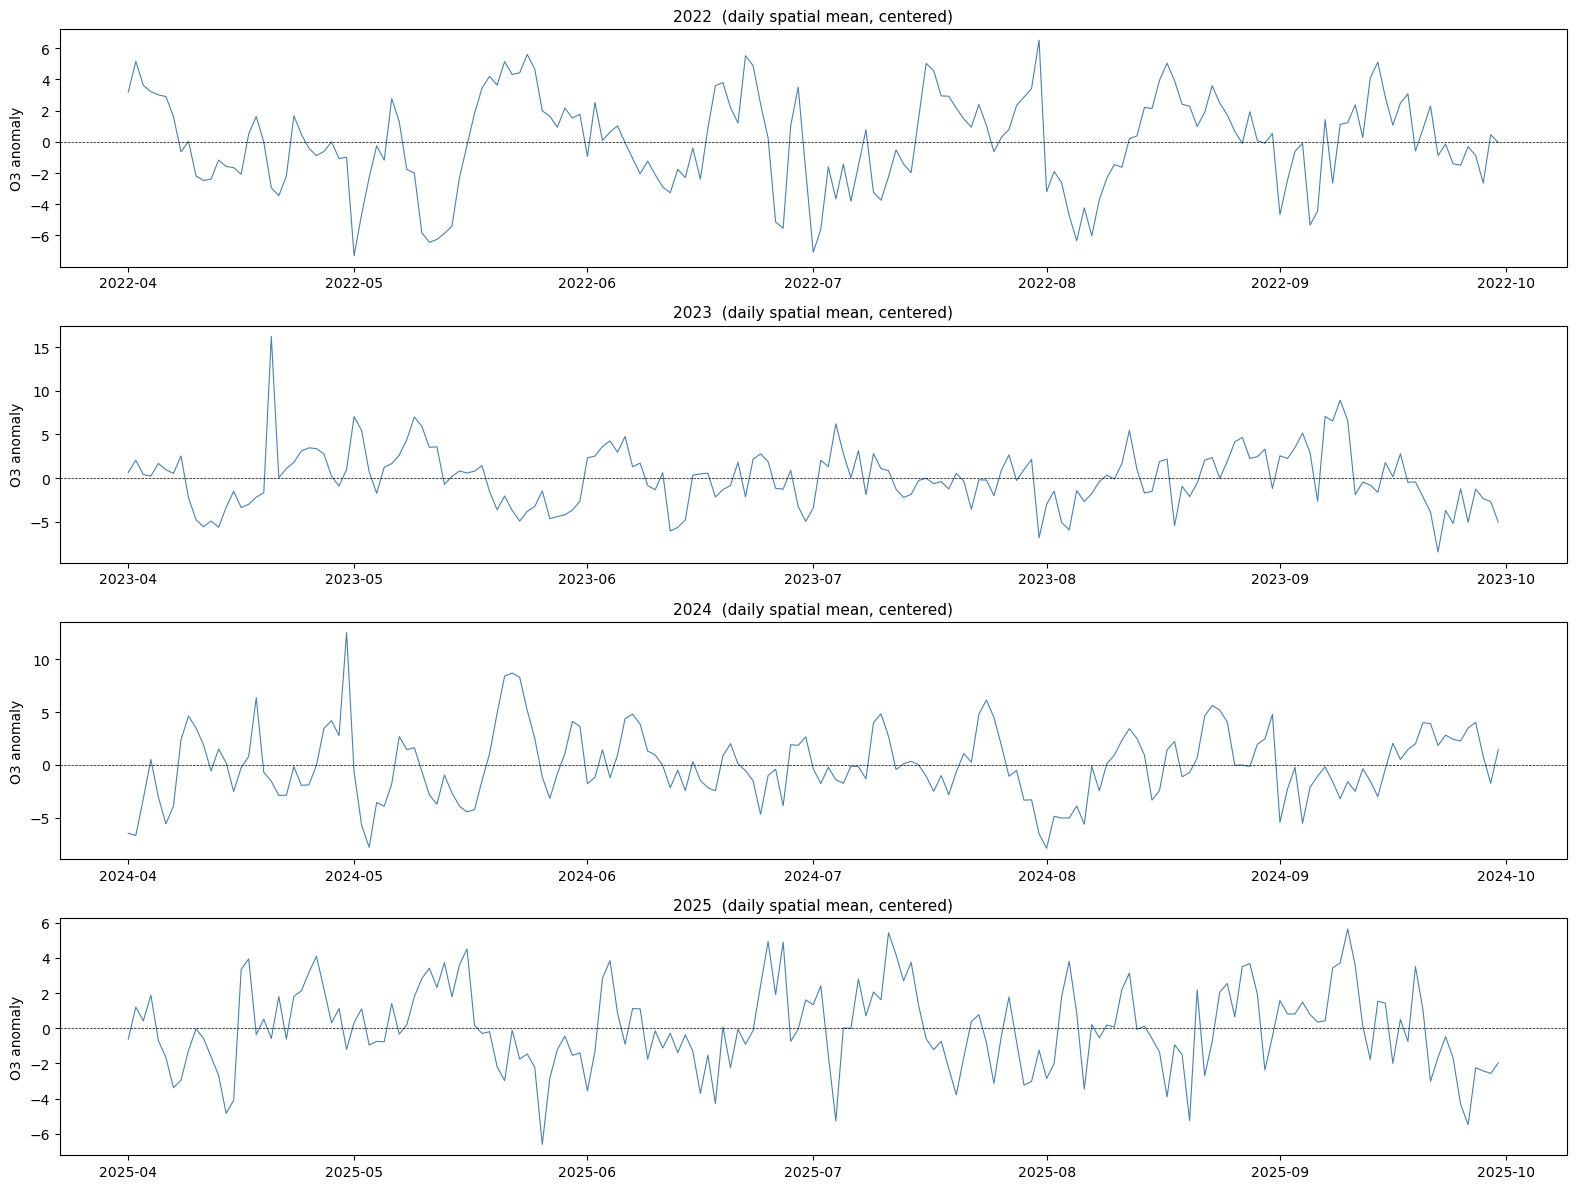

In [5]:
# ── Raw time series ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(len(YEARS), 1, figsize=(16, 3*len(YEARS)), sharex=False)
if len(YEARS) == 1: axes = [axes]

for ax, year in zip(axes, YEARS):
    ts = ts_daily[year]
    ax.plot(ts.index, ts.values, lw=0.8, color="steelblue")
    ax.axhline(0, color="k", lw=0.5, ls="--")
    ax.set_title(f"{year}  (daily spatial mean, centered)", fontsize=11)
    ax.set_ylabel("O3 anomaly")

plt.tight_layout()
plt.show()

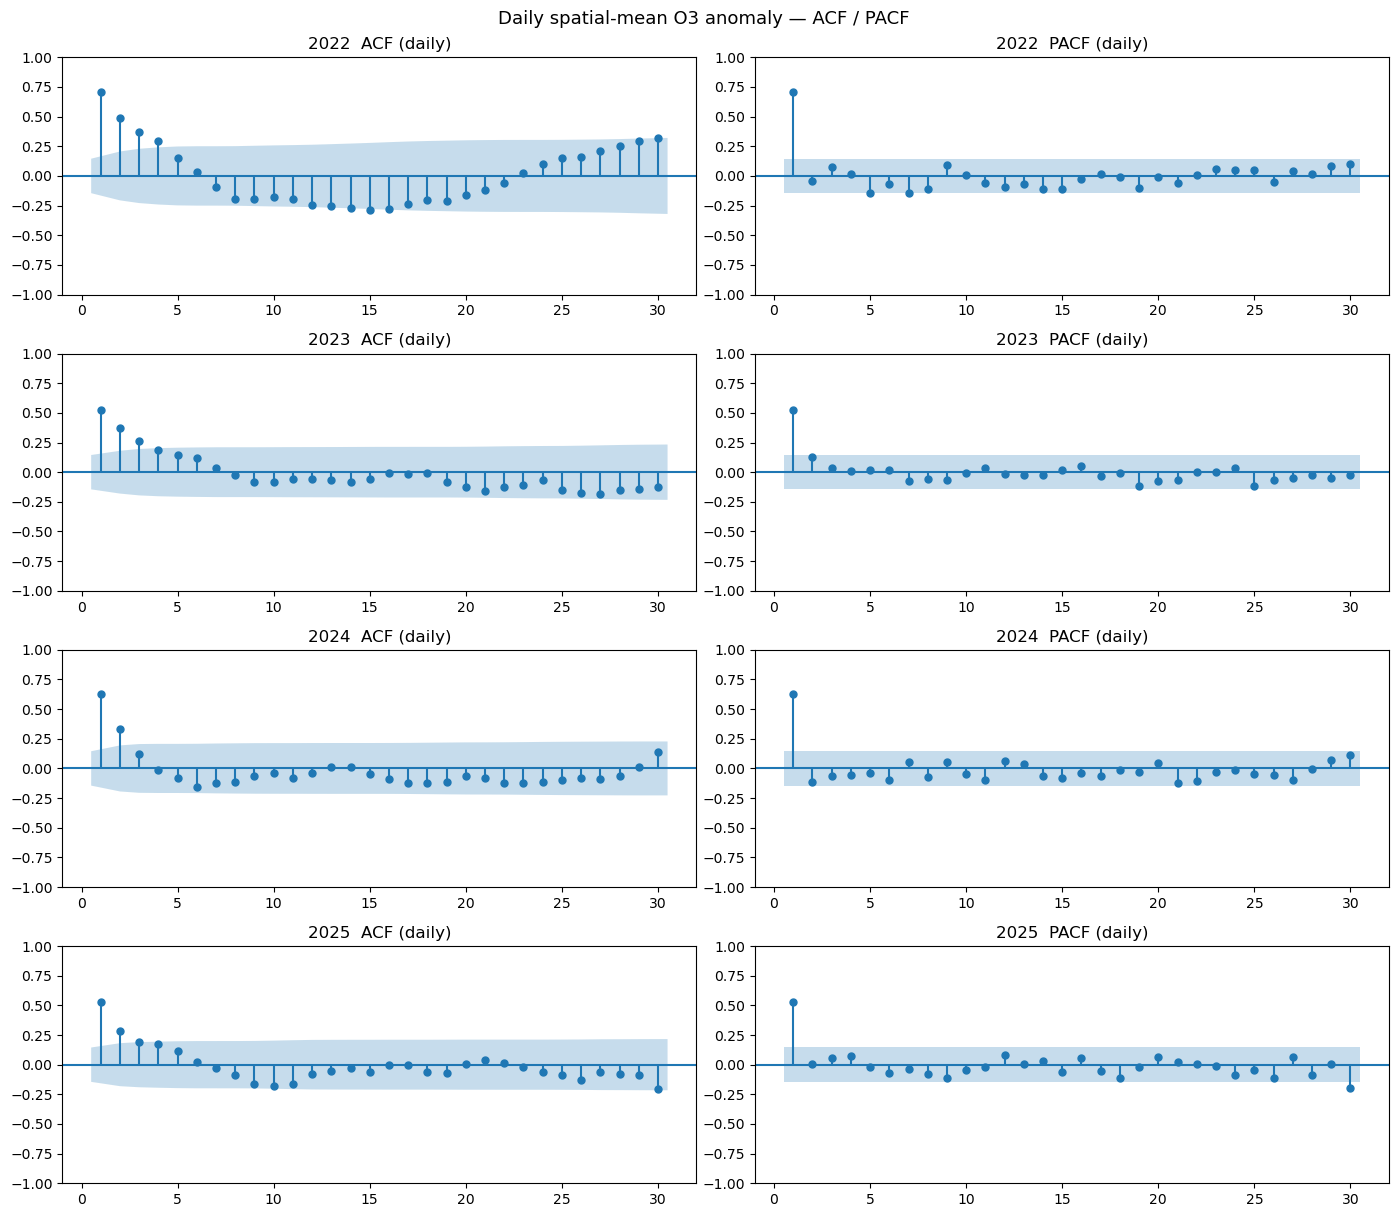

In [6]:
# ── ACF / PACF — daily time series ───────────────────────────────────────────
# AR(1): PACF cuts off after lag 1, ACF decays exponentially
N_LAGS = 30

fig, axes = plt.subplots(len(YEARS), 2, figsize=(14, 3*len(YEARS)))
if len(YEARS) == 1: axes = axes.reshape(1, -1)

for row, year in enumerate(YEARS):
    ts = ts_daily[year].dropna()
    plot_acf (ts, lags=N_LAGS, ax=axes[row, 0], title=f"{year}  ACF (daily)",  zero=False)
    plot_pacf(ts, lags=N_LAGS, ax=axes[row, 1], title=f"{year}  PACF (daily)", zero=False, method="ywm")

plt.tight_layout()
plt.suptitle("Daily spatial-mean O3 anomaly — ACF / PACF", y=1.01, fontsize=13)
plt.show()

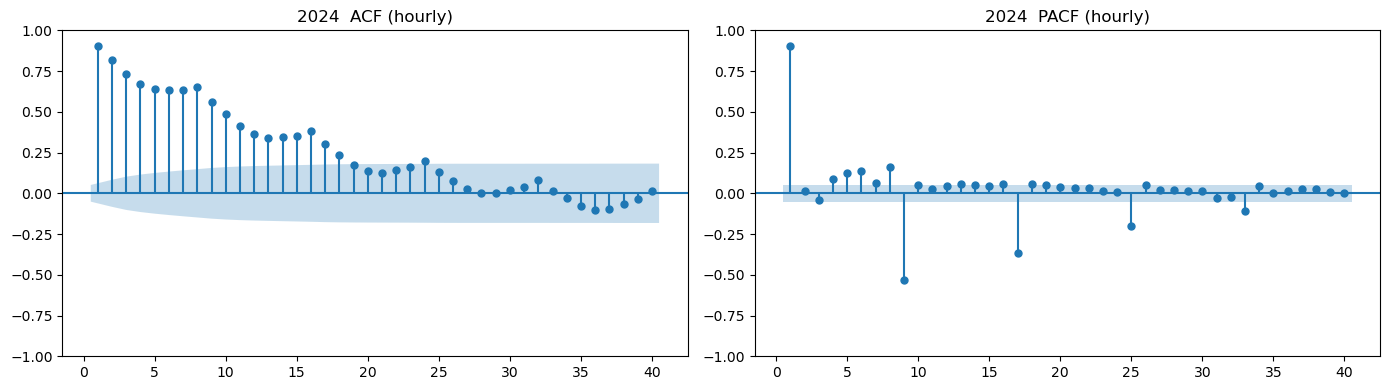

In [7]:
# ── ACF / PACF — hourly time series (within-day structure) ───────────────────
# Only first year for a clean look; repeat for others if needed
year_ex = 2024
ts_h = ts_hourly[year_ex].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf (ts_h, lags=40, ax=axes[0], title=f"{year_ex}  ACF (hourly)",  zero=False)
plot_pacf(ts_h, lags=40, ax=axes[1], title=f"{year_ex}  PACF (hourly)", zero=False, method="ywm")
plt.tight_layout()
plt.show()

## Step 3 — AR(p) 차수 선택 (AIC/BIC)

In [8]:
MAX_LAG = 10

def ar_order_selection(ts: pd.Series, max_lag: int = MAX_LAG, label: str = ""):
    """Fit AR(1)...AR(max_lag), return AIC/BIC table."""
    ts = ts.dropna()
    rows = []
    for p in range(1, max_lag + 1):
        try:
            res = AutoReg(ts, lags=p, old_names=False).fit()
            rows.append({"p": p, "AIC": res.aic, "BIC": res.bic})
        except Exception:
            pass
    df = pd.DataFrame(rows)
    df["ΔAIC"] = df["AIC"] - df["AIC"].min()
    df["ΔBIC"] = df["BIC"] - df["BIC"].min()
    if label:
        print(f"\n{label}")
        print(df.to_string(index=False, float_format="%.2f"))
    return df


aic_bic_results = {}
for year in YEARS:
    aic_bic_results[year] = ar_order_selection(
        ts_daily[year], label=f"Year {year} — daily spatial mean")


Year 2022 — daily spatial mean
 p    AIC    BIC  ΔAIC  ΔBIC
 1 780.35 789.94 29.32  2.43
 2 776.83 789.60 25.80  2.08
 3 774.38 790.32 23.35  2.80
 4 772.85 791.94 21.83  4.43
 5 767.73 789.97 16.71  2.45
 6 765.58 790.95 14.56  3.43
 7 760.36 788.84  9.34  1.33
 8 755.93 787.52  4.90  0.00
 9 752.96 787.65  1.94  0.13
10 751.02 788.79  0.00  1.28

Year 2023 — daily spatial mean
 p    AIC    BIC  ΔAIC  ΔBIC
 1 902.79 912.40 27.60  2.32
 2 897.29 910.08 22.11  0.00
 3 895.08 911.04 19.89  0.96
 4 893.14 912.26 17.95  2.18
 5 890.81 913.08 15.63  3.00
 6 888.81 914.22 13.63  4.14
 7 885.98 914.52 10.80  4.44
 8 883.04 914.69  7.86  4.61
 9 879.14 913.89  3.96  3.81
10 875.18 913.02  0.00  2.94

Year 2024 — daily spatial mean
 p    AIC    BIC  ΔAIC  ΔBIC
 1 855.92 865.54 34.69  7.70
 2 850.95 863.75 29.72  5.91
 3 848.48 864.44 27.25  6.61
 4 845.52 864.64 24.29  6.81
 5 840.84 863.11 19.61  5.28
 6 834.75 860.16 13.52  2.33
 7 832.33 860.87 11.10  3.03
 8 826.18 857.83  4.96  0.00
 9 82

/opt/anaconda3/envs/faiss_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/faiss_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/faiss_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/faiss_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information an

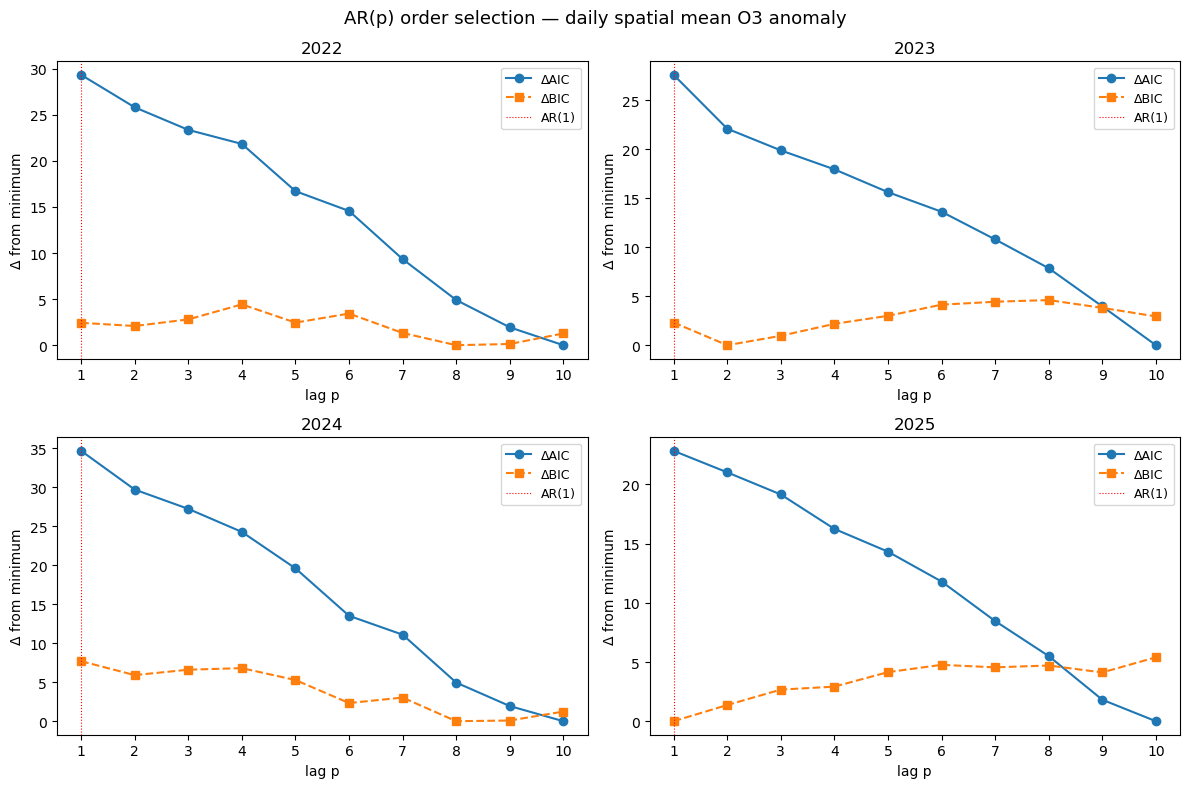

In [9]:
# Visualise AIC/BIC curves
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=False)
axes = axes.flatten()

for ax, year in zip(axes, YEARS):
    df = aic_bic_results[year]
    ax.plot(df["p"], df["ΔAIC"], marker="o", label="ΔAIC")
    ax.plot(df["p"], df["ΔBIC"], marker="s", label="ΔBIC", ls="--")
    ax.axvline(1, color="red", lw=0.8, ls=":", label="AR(1)")
    ax.set_title(f"{year}")
    ax.set_xlabel("lag p")
    ax.set_ylabel("Δ from minimum")
    ax.legend(fontsize=9)
    ax.set_xticks(range(1, MAX_LAG + 1))

plt.suptitle("AR(p) order selection — daily spatial mean O3 anomaly", fontsize=13)
plt.tight_layout()
plt.show()

## Step 4 — Ljung-Box test on AR(1) residuals

In [10]:
LB_LAGS = [5, 10, 20]

lb_summary = []

for year in YEARS:
    ts = ts_daily[year].dropna()
    ar1 = AutoReg(ts, lags=1, old_names=False).fit()
    resid = ar1.resid.dropna()

    lb = acorr_ljungbox(resid, lags=LB_LAGS, return_df=True)
    for lag, row in lb.iterrows():
        lb_summary.append({
            "year": year, "lag": int(lag),
            "LB_stat": round(row["lb_stat"], 3),
            "p_value": round(row["lb_pvalue"], 4),
            "reject_5%": row["lb_pvalue"] < 0.05
        })

lb_df = pd.DataFrame(lb_summary)
print("Ljung-Box test on AR(1) residuals (H0: no autocorrelation)")
print(lb_df.to_string(index=False))

Ljung-Box test on AR(1) residuals (H0: no autocorrelation)
 year  lag  LB_stat  p_value  reject_5%
 2022    5    4.475   0.4832      False
 2022   10   12.669   0.2427      False
 2022   20   20.508   0.4266      False
 2023    5    3.248   0.6617      False
 2023   10    5.146   0.8812      False
 2023   20    8.153   0.9908      False
 2024    5    2.731   0.7414      False
 2024   10    8.605   0.5700      False
 2024   20   15.306   0.7586      False
 2025    5    2.199   0.8210      False
 2025   10    4.926   0.8961      False
 2025   20   11.145   0.9424      False


/opt/anaconda3/envs/faiss_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


/opt/anaconda3/envs/faiss_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


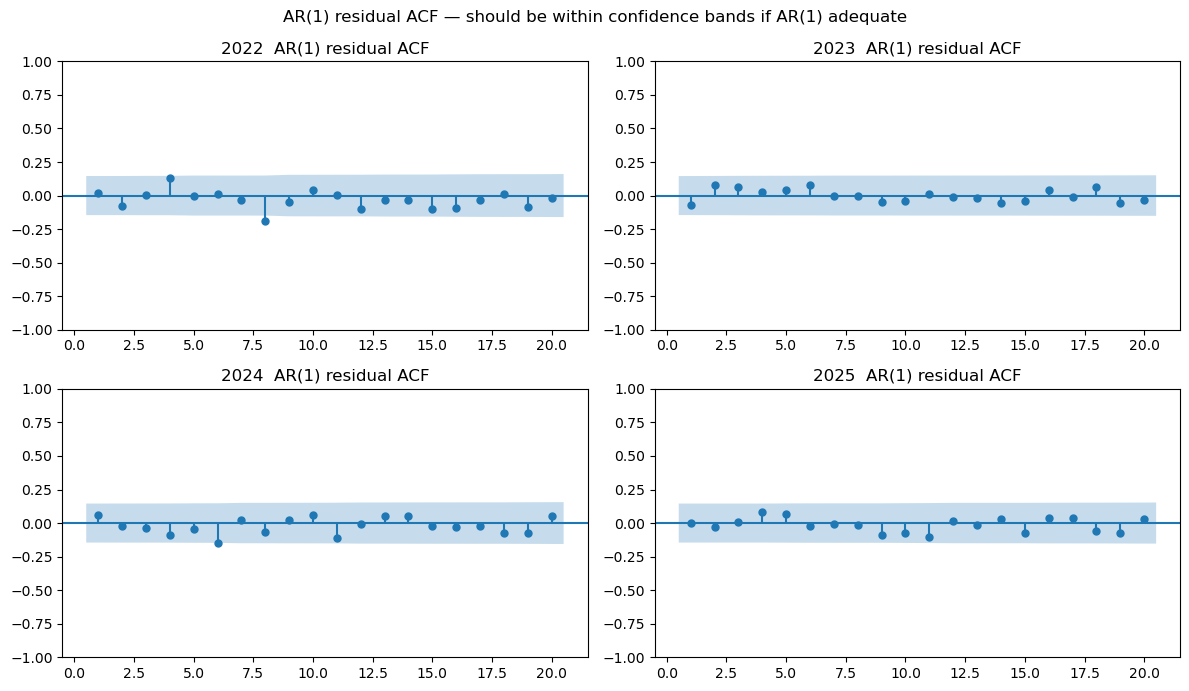

In [11]:
# AR(1) residual ACF — should look like white noise if AR(1) is adequate
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes = axes.flatten()

for ax, year in zip(axes, YEARS):
    ts   = ts_daily[year].dropna()
    ar1  = AutoReg(ts, lags=1, old_names=False).fit()
    plot_acf(ar1.resid.dropna(), lags=20, ax=ax, zero=False,
             title=f"{year}  AR(1) residual ACF")

plt.suptitle("AR(1) residual ACF — should be within confidence bands if AR(1) adequate",
             fontsize=12)
plt.tight_layout()
plt.show()

## Step 5 — 고정 격자점 분석 (공간 평균이 아닌 개별 위치)

  (-1.0, 124.0) [center]: 182 days, NaN=0
  (1.5, 128.0) [NE]: 182 days, NaN=0
  (-2.5, 122.0) [SW]: 182 days, NaN=0


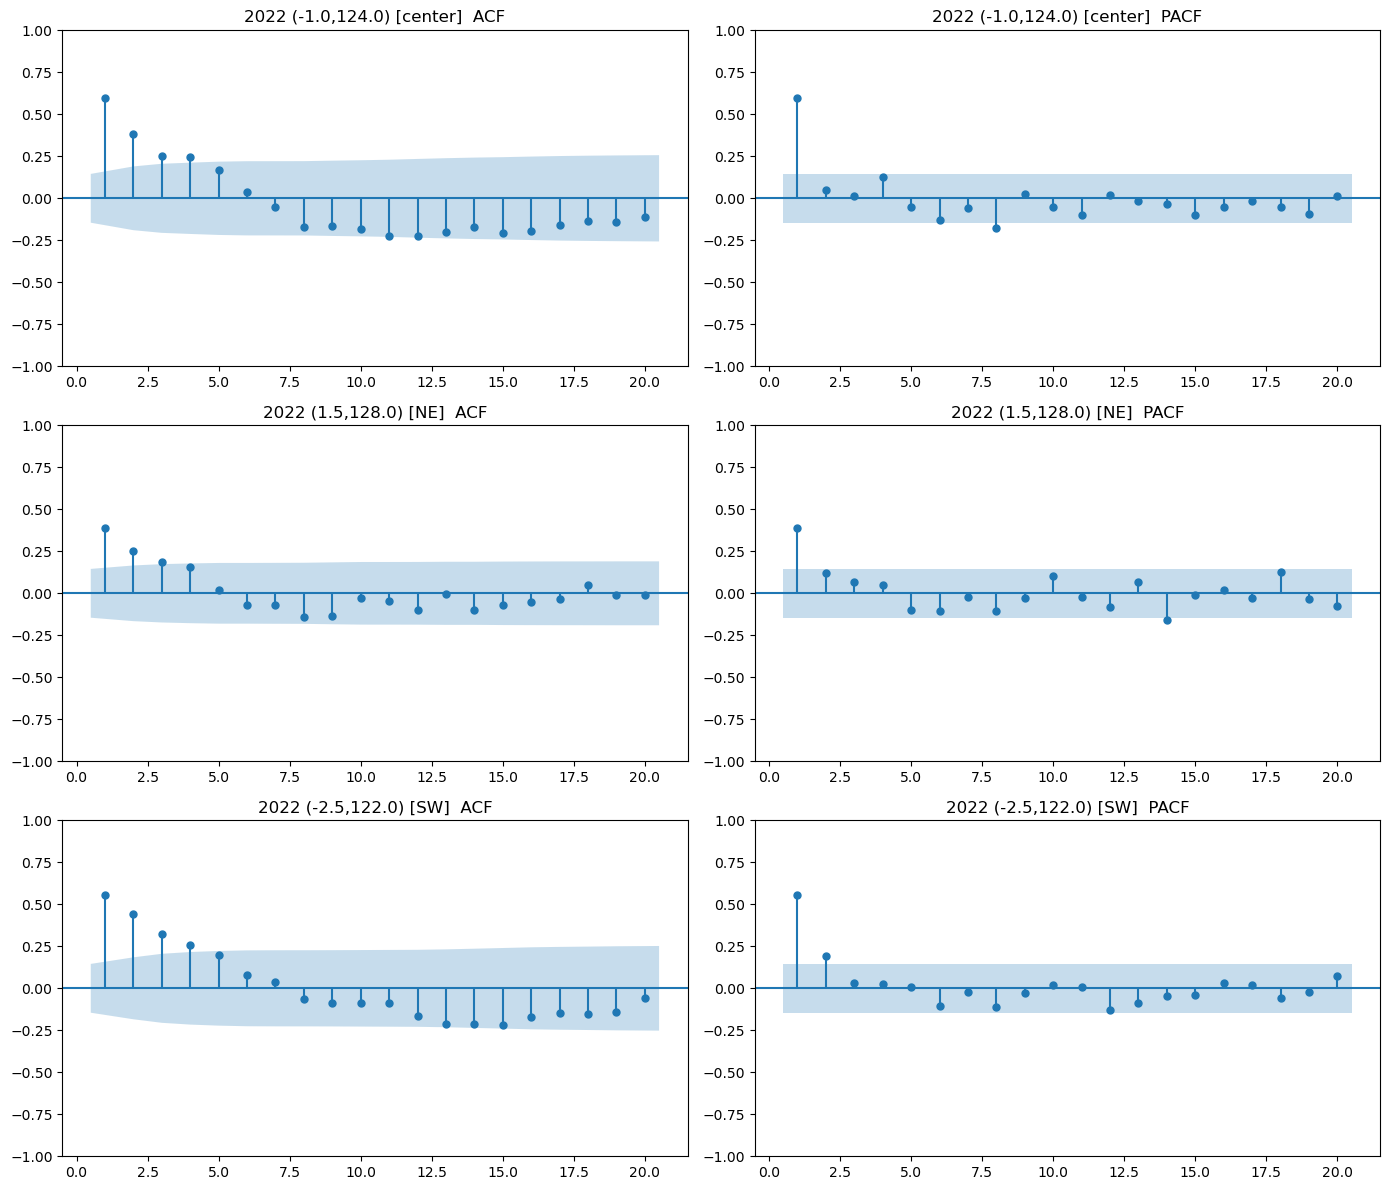

In [17]:
# Representative grid points (lat, lon) — adjust as needed
PROBE_POINTS = [
    (-1.0, 124.0, "center"),
    ( 1.5, 128.0, "NE"),
    (-2.5, 122.0, "SW"),
]

# Use one year as representative for the point-level analysis
year_probe = 2022

fig, axes = plt.subplots(len(PROBE_POINTS), 2,
                         figsize=(14, 4 * len(PROBE_POINTS)))
if len(PROBE_POINTS) == 1: axes = axes.reshape(1, -1)

for row_i, (lat, lon, label) in enumerate(PROBE_POINTS):
    ts_pt = extract_time_series(year_probe, kind="grid_point",
                                target_lat=lat, target_lon=lon, center=True)
    ts_pt_daily = daily_mean_ts(ts_pt).dropna()

    n_nan = ts_pt_daily.isna().sum()
    print(f"  ({lat}, {lon}) [{label}]: {len(ts_pt_daily)} days, NaN={n_nan}")

    plot_acf (ts_pt_daily, lags=20, ax=axes[row_i, 0], zero=False,
              title=f"{year_probe} ({lat},{lon}) [{label}]  ACF")
    plot_pacf(ts_pt_daily, lags=20, ax=axes[row_i, 1], zero=False,
              title=f"{year_probe} ({lat},{lon}) [{label}]  PACF", method="ywm")

plt.tight_layout()
plt.show()

## Step 6 — 연도별 AR(1) 계수 비교

In [13]:
coef_rows = []
for year in YEARS:
    ts = ts_daily[year].dropna()
    ar1 = AutoReg(ts, lags=1, old_names=False).fit()
    phi = ar1.params["O3.L1"] if "O3.L1" in ar1.params.index else ar1.params.iloc[1]
    se  = ar1.bse.iloc[1]
    coef_rows.append({
        "year": year,
        "phi_1":   round(phi, 4),
        "SE":      round(se, 4),
        "phi±2SE": f"[{phi-2*se:.3f}, {phi+2*se:.3f}]",
        "n_days":  len(ts),
        "AIC_AR1": round(ar1.aic, 1),
        "BIC_AR1": round(ar1.bic, 1),
    })

coef_df = pd.DataFrame(coef_rows)
print("AR(1) coefficient φ₁ by year (daily spatial-mean O3 anomaly)")
print(coef_df.to_string(index=False))

AR(1) coefficient φ₁ by year (daily spatial-mean O3 anomaly)
 year  phi_1     SE        phi±2SE  n_days  AIC_AR1  BIC_AR1
 2022 0.7115 0.0519 [0.608, 0.815]     182    780.3    789.9
 2023 0.5317 0.0633 [0.405, 0.658]     183    902.8    912.4
 2024 0.6315 0.0565 [0.519, 0.744]     183    855.9    865.5
 2025 0.5338 0.0628 [0.408, 0.660]     183    773.2    782.8


/opt/anaconda3/envs/faiss_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


## Step 7 — 요약 및 결론

In [14]:
print("=" * 65)
print("  AR(1) Adequacy Summary")
print("=" * 65)

for year in YEARS:
    ts    = ts_daily[year].dropna()
    ar1   = AutoReg(ts, lags=1, old_names=False).fit()
    resid = ar1.resid.dropna()
    lb10  = acorr_ljungbox(resid, lags=[10], return_df=True)
    pval  = float(lb10["lb_pvalue"].iloc[0])

    # AIC: is AR(1) within 2 units of best AR(p)?
    df_aic = aic_bic_results[year]
    aic_ar1 = float(df_aic.loc[df_aic["p"] == 1, "ΔAIC"].values[0])

    adequate = (pval >= 0.05) and (aic_ar1 <= 2.0)
    verdict  = "✓ AR(1) adequate" if adequate else "✗ AR(1) may be insufficient"

    print(f"  {year}: LB(10) p={pval:.3f}  ΔAIC_AR1={aic_ar1:.2f}  → {verdict}")

print("=" * 65)
print()
print("Note: analysis based on daily spatial-mean O3 anomaly (centered by monthly mean).")
print("Point-level results may differ due to local NaN patterns.")

  AR(1) Adequacy Summary
  2022: LB(10) p=0.243  ΔAIC_AR1=29.32  → ✗ AR(1) may be insufficient
  2023: LB(10) p=0.881  ΔAIC_AR1=27.60  → ✗ AR(1) may be insufficient
  2024: LB(10) p=0.570  ΔAIC_AR1=34.69  → ✗ AR(1) may be insufficient
  2025: LB(10) p=0.896  ΔAIC_AR1=22.83  → ✗ AR(1) may be insufficient

Note: analysis based on daily spatial-mean O3 anomaly (centered by monthly mean).
Point-level results may differ due to local NaN patterns.


/opt/anaconda3/envs/faiss_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
